In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    f1_score, matthews_corrcoef, classification_report,
    confusion_matrix
)
from xgboost import XGBClassifier
import xgboost as xgb

RANDOM_STATE = 42
LEAKAGE_PRONE_FEATURES = ["PageValues", "BounceRates", "ExitRates"]


c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("online_shoppers_intention.csv")
NOMINAL_INT_COLS = ["OperatingSystems", "Browser", "Region", "TrafficType"]
df[NOMINAL_INT_COLS] = df[NOMINAL_INT_COLS].astype("category")
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)

y = df_encoded["Revenue"]
X_main = df_encoded.drop("Revenue", axis=1)
X_early = X_main.drop(columns=LEAKAGE_PRONE_FEATURES)

# Sanity check: confirm the full-feature split matches every other notebook's split
X_train_check, X_test_check, y_train_check, y_test_check = train_test_split(
    X_main, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_test_raw_saved = pd.read_csv("X_test_raw.csv")
assert X_test_check.reset_index(drop=True).equals(X_test_raw_saved.reset_index(drop=True)), \
    "Split does not match analysis.ipynb / RandomForest.ipynb!"
print("Split confirmed identical to the rest of the project.")
print("X_main shape :", X_main.shape)
print("X_early shape:", X_early.shape)


Split confirmed identical to the rest of the project.
X_main shape : (12330, 68)
X_early shape: (12330, 65)


In [3]:
def fit_and_score_xgb(X, y, label):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
    )
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    scale_pos_weight = neg / pos

    model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        scale_pos_weight=scale_pos_weight,
        base_score=0.5,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_train_s, y_train)

    y_prob = model.predict_proba(X_test_s)[:, 1]
    y_pred = model.predict(X_test_s)

    row = {
        "Feature set": label,
        "Model": "XGBoost",
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4),
        "PR-AUC": round(average_precision_score(y_test, y_prob), 4),
        "F1": round(f1_score(y_test, y_pred), 4),
        "MCC": round(matthews_corrcoef(y_test, y_pred), 4),
    }
    return row, model, X_train_s, X_test_s, y_train, y_test, scaler


In [4]:
(xgb_full_row, xgb_full_model,
 X_train_s_full, X_test_s_full, y_train_full, y_test_full, scaler_full) = fit_and_score_xgb(
    X_main, y, "Full feature set (with PageValues/BounceRates/ExitRates)"
)

(xgb_early_row, xgb_early_model,
 X_train_s_early, X_test_s_early, y_train_early, y_test_early, scaler_early) = fit_and_score_xgb(
    X_early, y, "Early-prediction (excluding PageValues/BounceRates/ExitRates)"
)

xgb_results_df = pd.DataFrame([xgb_full_row, xgb_early_row])
xgb_results_df


,Feature set,Model,Accuracy,ROC-AUC,PR-AUC,F1,MCC
0,Full feature set (with PageValues/BounceRates/...,XGBoost,0.8820,0.9225,0.7164,0.6540,0.5871
1,Early-prediction (excluding PageValues/BounceR...,XGBoost,0.7575,0.7325,0.3195,0.3692,0.2327


In [ ]:
from sklearn.metrics import precision_score, recall_score

# Full feature set (sanity check — should match cell 6's 0.5991 / 0.7199)
y_pred_xgb_full = xgb_full_model.predict(X_test_s_full)
precision_xgb_full = precision_score(y_test_full, y_pred_xgb_full)
recall_xgb_full = recall_score(y_test_full, y_pred_xgb_full)
print("XGBoost (full feature set) Precision:", round(precision_xgb_full, 4))
print("XGBoost (full feature set) Recall:", round(recall_xgb_full, 4))

# Leakage-free feature set — this is the missing Table 3 row
y_pred_xgb_early = xgb_early_model.predict(X_test_s_early)
precision_xgb_early = precision_score(y_test_early, y_pred_xgb_early)
recall_xgb_early = recall_score(y_test_early, y_pred_xgb_early)
print("XGBoost (leakage-free feature set) Precision:", round(precision_xgb_early, 4))
print("XGBoost (leakage-free feature set) Recall:", round(recall_xgb_early, 4))


XGBoost (full feature set) Precision: 0.5991
XGBoost (full feature set) Recall: 0.7199
XGBoost (leakage-free feature set) Precision: 0.3092
XGBoost (leakage-free feature set) Recall: 0.4581


In [6]:
from sklearn.metrics import precision_score, recall_score

# Full feature set (sanity check — should match cell 6's 0.5991 / 0.7199)
y_pred_xgb_full = xgb_full_model.predict(X_test_s_full)
precision_xgb_full = precision_score(y_test_full, y_pred_xgb_full)
recall_xgb_full = recall_score(y_test_full, y_pred_xgb_full)
print("XGBoost (full feature set) Precision:", round(precision_xgb_full, 4))
print("XGBoost (full feature set) Recall:", round(recall_xgb_full, 4))

# Leakage-free feature set — this is the missing Table 3 row
y_pred_xgb_early = xgb_early_model.predict(X_test_s_early)
precision_xgb_early = precision_score(y_test_early, y_pred_xgb_early)
recall_xgb_early = recall_score(y_test_early, y_pred_xgb_early)
print("XGBoost (leakage-free feature set) Precision:", round(precision_xgb_early, 4))
print("XGBoost (leakage-free feature set) Recall:", round(recall_xgb_early, 4))

XGBoost (full feature set) Precision: 0.5991
XGBoost (full feature set) Recall: 0.7199
XGBoost (leakage-free feature set) Precision: 0.3092
XGBoost (leakage-free feature set) Recall: 0.4581


In [7]:
X_test_s_full_df = pd.DataFrame(X_test_s_full, columns=X_main.columns)
explainer_xgb_full = shap.TreeExplainer(
    xgb_full_model, feature_perturbation="tree_path_dependent"
)  # matches RF's TreeExplainer config in SHAP.ipynb — confirms explainer parity for reviewer Q2
shap_values_xgb_full = explainer_xgb_full.shap_values(X_test_s_full_df)

mean_abs_shap_xgb_full = np.abs(shap_values_xgb_full).mean(axis=0)
shap_importance_table_xgb = pd.DataFrame({
    "Feature": X_main.columns,
    "Mean |SHAP Value| (XGB)": mean_abs_shap_xgb_full,  # renamed for consistency with LR/RF tables
}).sort_values("Mean |SHAP Value| (XGB)", ascending=False).reset_index(drop=True)

shap_importance_table_xgb.to_csv("shap_importance_table_xgb.csv", index=False)
shap_importance_table_xgb.head(10)

,Feature,Mean |SHAP Value| (XGB)
0,PageValues,2.381890
1,Month_May,0.702140
2,ExitRates,0.555186
3,Month_Nov,0.395315
4,Month_Mar,0.380153
5,ProductRelated_Duration,0.303638
6,BounceRates,0.233740
7,ProductRelated,0.213667
8,Administrative_Duration,0.213203
9,Administrative,0.136507


In [8]:
from sklearn.metrics import precision_score, recall_score

y_pred_xgb_full = xgb_full_model.predict(X_test_s_full)
precision_xgb_full = precision_score(y_test_full, y_pred_xgb_full)
recall_xgb_full = recall_score(y_test_full, y_pred_xgb_full)

print("XGBoost (full feature set) Precision:", round(precision_xgb_full, 4))
print("XGBoost (full feature set) Recall:", round(recall_xgb_full, 4))

XGBoost (full feature set) Precision: 0.5991
XGBoost (full feature set) Recall: 0.7199


In [9]:
model_comparison = pd.read_csv("model_comparison_lr_vs_rf.csv")

xgb_full_model_row = pd.DataFrame([{
    "Model": "XGBoost",
    "Accuracy": xgb_full_row["Accuracy"],
    "AUC": xgb_full_row["ROC-AUC"],
    "Interpretable by design?": "No (gradient-boosted ensemble)"
}])

model_comparison_lr_rf_xgb = pd.concat([model_comparison, xgb_full_model_row], ignore_index=True)
model_comparison_lr_rf_xgb.to_csv("model_comparison_lr_rf_xgb.csv", index=False)
model_comparison_lr_rf_xgb


,Model,Accuracy,AUC,Interpretable by design?
0,Logistic Regression,0.8366,0.8918,Yes (coefficients)
1,Random Forest,0.8861,0.9241,No (ensemble of 300 trees)
2,XGBoost,0.8820,0.9225,No (gradient-boosted ensemble)


In [10]:
leakage_results = pd.read_csv("leakage_ablation_results.csv")

leakage_results_with_xgb = pd.concat([leakage_results, xgb_results_df], ignore_index=True)
leakage_results_with_xgb.to_csv("leakage_ablation_results_with_xgb.csv", index=False)
leakage_results_with_xgb


,Feature set,Model,Accuracy,ROC-AUC,PR-AUC,F1,MCC
0,Full feature set (with PageValues/BounceRates/...,Logistic Regression,0.8366,0.8918,0.6208,0.5832,0.5042
1,Full feature set (with PageValues/BounceRates/...,Random Forest,0.8861,0.9241,0.7221,0.6602,0.5947
2,Early-prediction (excluding PageValues/BounceR...,Logistic Regression,0.6565,0.7164,0.3088,0.3749,0.2368
3,Early-prediction (excluding PageValues/BounceR...,Random Forest,0.7976,0.7578,0.3515,0.3817,0.2616
4,Full feature set (with PageValues/BounceRates/...,XGBoost,0.8820,0.9225,0.7164,0.6540,0.5871
5,Early-prediction (excluding PageValues/BounceR...,XGBoost,0.7575,0.7325,0.3195,0.3692,0.2327


In [11]:
X_test_s_early_df = pd.DataFrame(X_test_s_early, columns=X_early.columns)

dtest_early = xgb.DMatrix(X_test_s_early_df)
booster_early = xgb_early_model.get_booster()

# pred_contribs=True returns XGBoost's native TreeSHAP values: shape (n_samples, n_features + 1),
# where the last column is the bias/base-value term (equivalent to explainer.expected_value).
shap_contribs_xgb = booster_early.predict(dtest_early, pred_contribs=True)
shap_values_xgb = shap_contribs_xgb[:, :-1]
base_value_xgb = shap_contribs_xgb[:, -1].mean()

print("SHAP values shape:", shap_values_xgb.shape)
print("Mean base value (expected value):", round(base_value_xgb, 4))


SHAP values shape: (2466, 65)
Mean base value (expected value): 0.1122


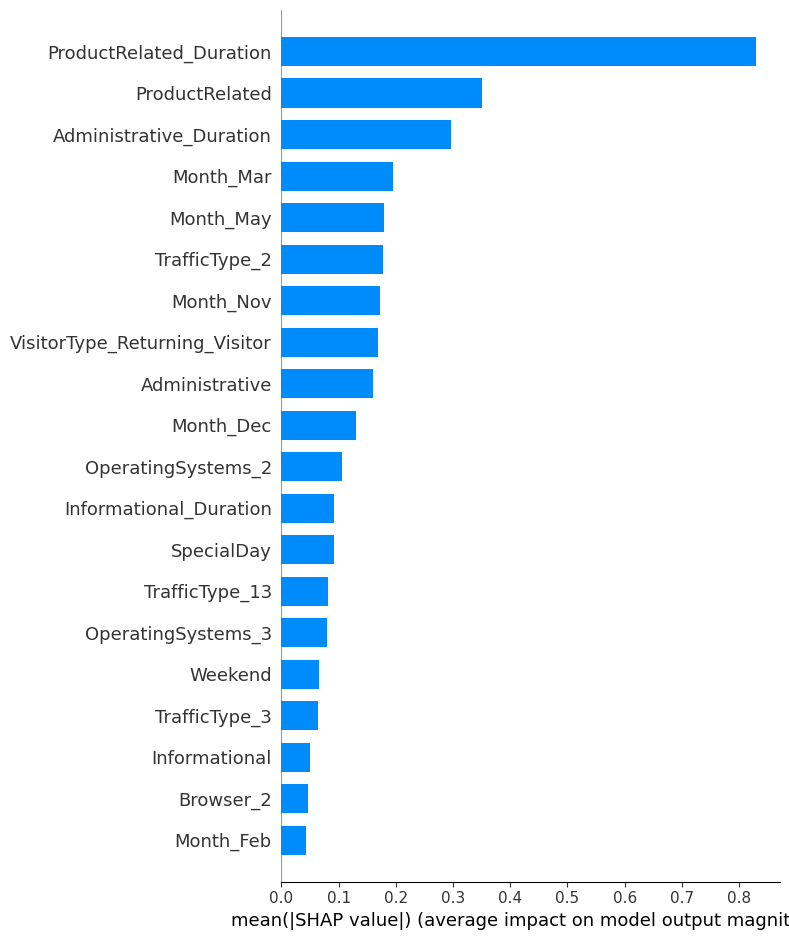

In [12]:
shap.summary_plot(shap_values_xgb, X_test_s_early_df, plot_type="bar", show=True)


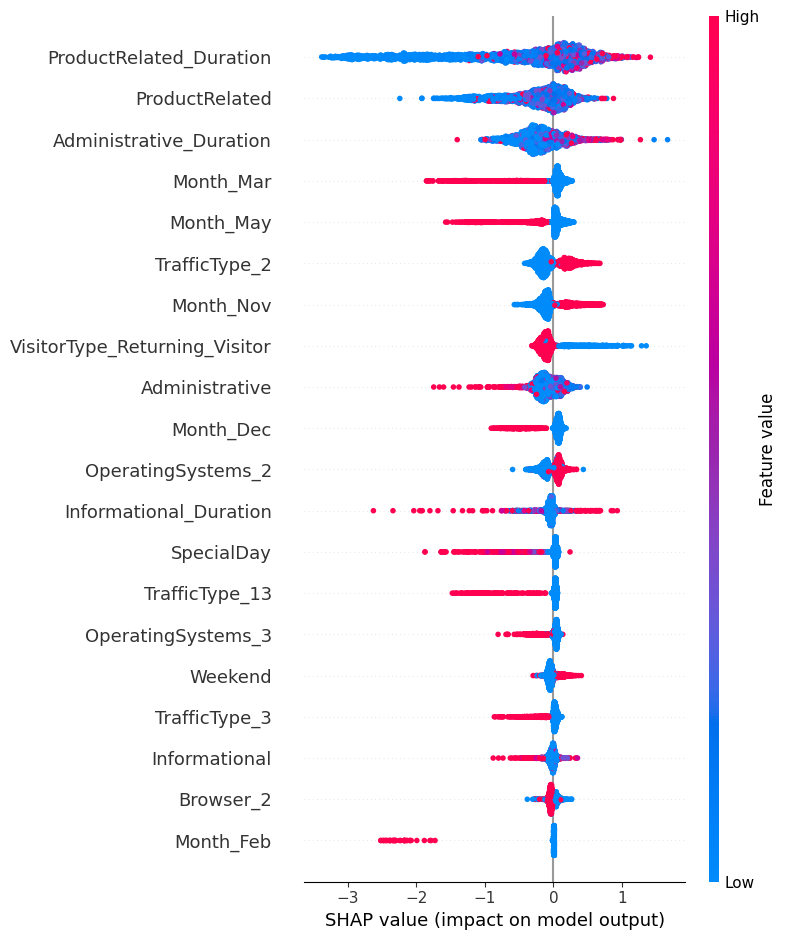

In [13]:
shap.summary_plot(shap_values_xgb, X_test_s_early_df, show=True)


In [14]:
mean_abs_shap_xgb = np.abs(shap_values_xgb).mean(axis=0)

xgb_shap_importance = pd.DataFrame({
    "feature": X_early.columns,
    "mean_abs_shap": mean_abs_shap_xgb
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
xgb_shap_importance["rank"] = xgb_shap_importance.index + 1

xgb_shap_importance.to_csv("shap_importance_table_xgb_early.csv", index=False)
xgb_shap_importance.head(10)


,feature,mean_abs_shap,rank
0,ProductRelated_Duration,0.830112,1
1,ProductRelated,0.349742,2
2,Administrative_Duration,0.296920,3
3,Month_Mar,0.194895,4
4,Month_May,0.179382,5
5,TrafficType_2,0.177265,6
6,Month_Nov,0.172344,7
7,VisitorType_Returning_Visitor,0.168019,8
8,Administrative,0.160309,9
9,Month_Dec,0.129856,10


In [15]:
rf_early_importance = pd.read_csv("shap_importance_table_rf_early.csv")

three_way = rf_early_importance.merge(
    xgb_shap_importance, on="feature", suffixes=("_rf", "_xgb")
)
three_way = three_way.rename(columns={
    "rank_rf": "RF Rank (leakage-free)",
    "rank_xgb": "XGBoost Rank (leakage-free)",
    "mean_abs_shap_rf": "RF Mean |SHAP|",
    "mean_abs_shap_xgb": "XGBoost Mean |SHAP|",
})
three_way["Rank Difference (RF vs XGBoost)"] = (
    three_way["RF Rank (leakage-free)"] - three_way["XGBoost Rank (leakage-free)"]
).abs()

three_way = three_way.sort_values("RF Rank (leakage-free)").reset_index(drop=True)
three_way.to_csv("shap_comparison_rf_vs_xgb_early.csv", index=False)
three_way[[
    "feature", "RF Rank (leakage-free)", "XGBoost Rank (leakage-free)",
    "Rank Difference (RF vs XGBoost)"
]].head(15)


,feature,RF Rank (leakage-free),XGBoost Rank (leakage-free),Rank Difference (RF vs XGBoost)
0,ProductRelated_Duration,1,1,0
1,Month_Nov,2,7,5
2,ProductRelated,3,2,1
3,Administrative_Duration,4,3,1
4,TrafficType_2,5,6,1
5,VisitorType_Returning_Visitor,6,8,2
6,Administrative,7,9,2
7,OperatingSystems_2,8,11,3
8,SpecialDay,9,13,4
9,OperatingSystems_3,10,15,5


In [16]:
from scipy.stats import spearmanr

rho, p = spearmanr(
    three_way["RF Rank (leakage-free)"], three_way["XGBoost Rank (leakage-free)"]
)
print(f"Spearman rank correlation between RF and XGBoost SHAP rankings (leakage-free): "
      f"rho = {rho:.3f}, p = {p:.4g}")


Spearman rank correlation between RF and XGBoost SHAP rankings (leakage-free): rho = 0.965, p = 2.917e-38


## 6. ALE validation — is the SHAP ranking an artifact of SHAP itself?
Same `PyALE` approach already used for Random Forest in `Additional_analysis.ipynb`, applied here
to the XGBoost model on the same four features, so the two sets of ALE curves are directly
comparable. ALE gives a model-agnostic global effect curve for each feature; if a feature's ALE
shape/direction agrees with its SHAP ranking, that ranking is unlikely to be an artifact of SHAP's
attribution method specifically.

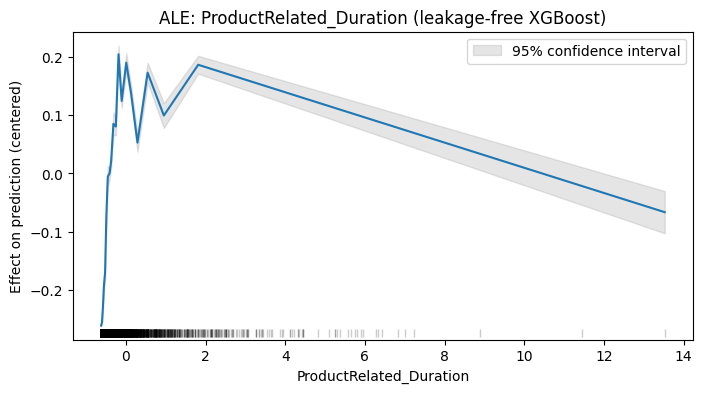

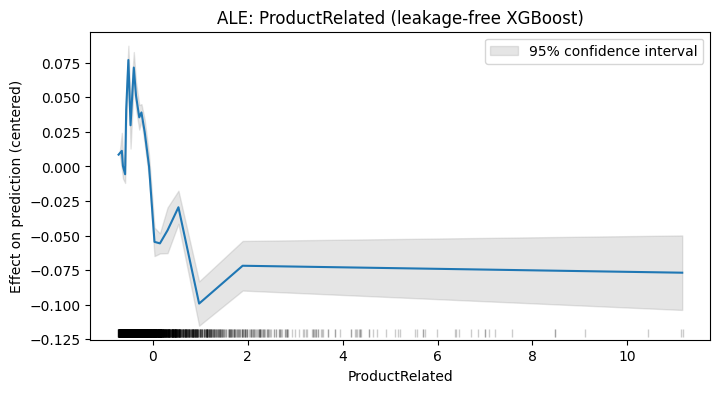

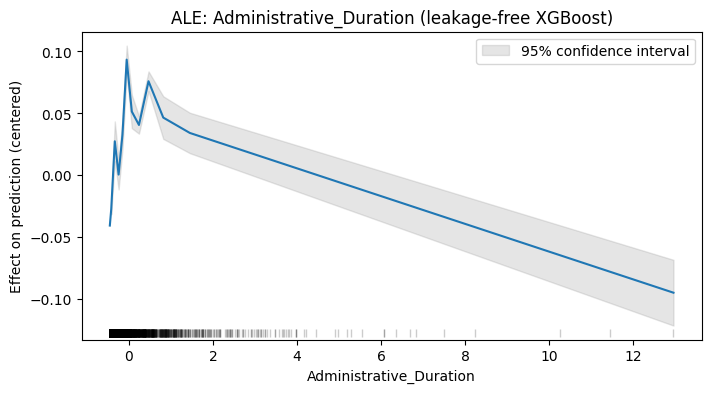

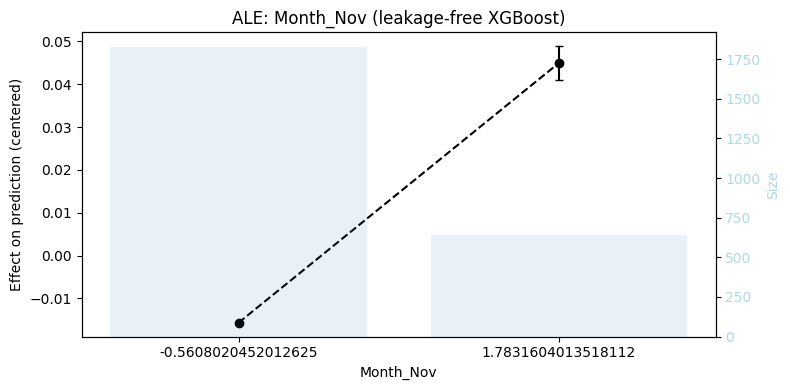

In [17]:
from PyALE import ale

class ProbaWrapper:
    def __init__(self, fitted_model):
        self.model = fitted_model
    def predict(self, X):
        return self.model.predict_proba(X)[:, 1]

xgb_wrapped = ProbaWrapper(xgb_early_model)

ale_features = [
    ("ProductRelated_Duration", "continuous"),
    ("ProductRelated", "continuous"),
    ("Administrative_Duration", "continuous"),
    ("Month_Nov", "discrete"),
]

for feat, ftype in ale_features:
    ale_eff = ale(
        X=X_test_s_early_df, model=xgb_wrapped, feature=[feat],
        feature_type=ftype, grid_size=20, include_CI=True
    )
    plt.title(f"ALE: {feat} (leakage-free XGBoost)")
    plt.savefig(f"ale_xgb_{feat}.png", dpi=200, bbox_inches="tight")
    plt.show()


Top XGBoost feature (leakage-free): ProductRelated_Duration


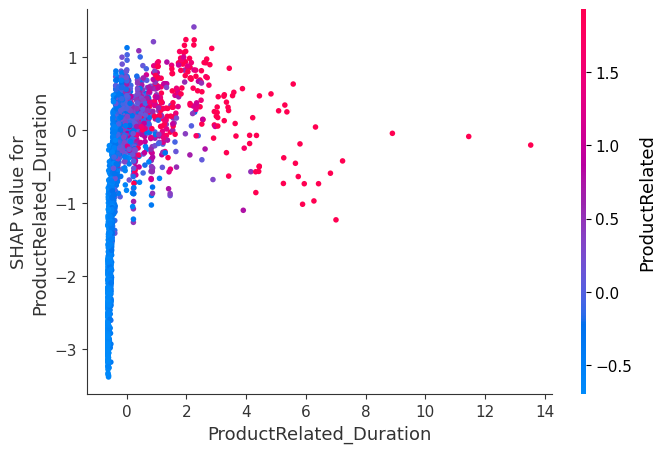

In [18]:
top_feature_xgb = xgb_shap_importance.iloc[0]["feature"]
print("Top XGBoost feature (leakage-free):", top_feature_xgb)

shap.dependence_plot(top_feature_xgb, shap_values_xgb, X_test_s_early_df, show=True)


c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature

                   feature feature_type  PDI_RF_vs_XGBoost
0  ProductRelated_Duration   continuous             0.1053
1           ProductRelated   continuous             0.2000
2  Administrative_Duration   continuous             0.1818
3                Month_Nov     discrete             0.0000

Mean PDI across features: 0.1218


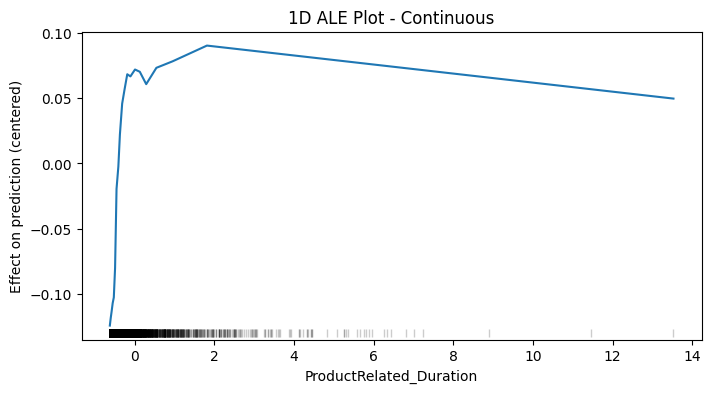

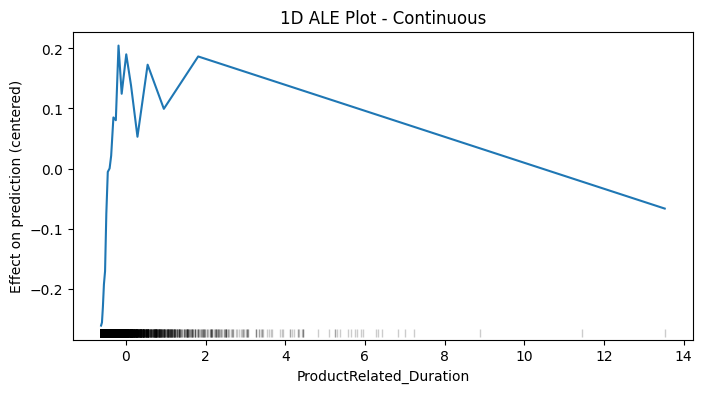

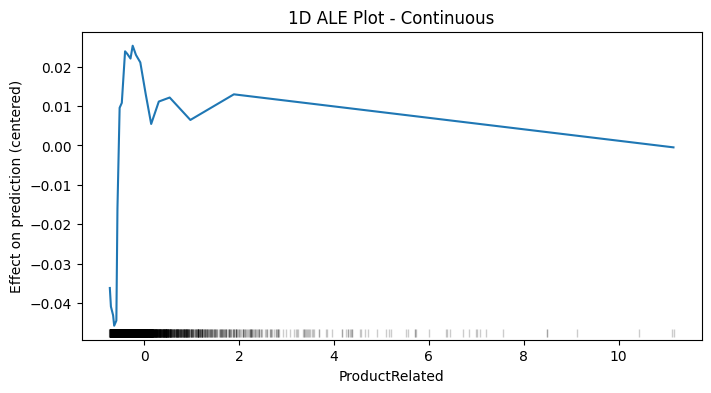

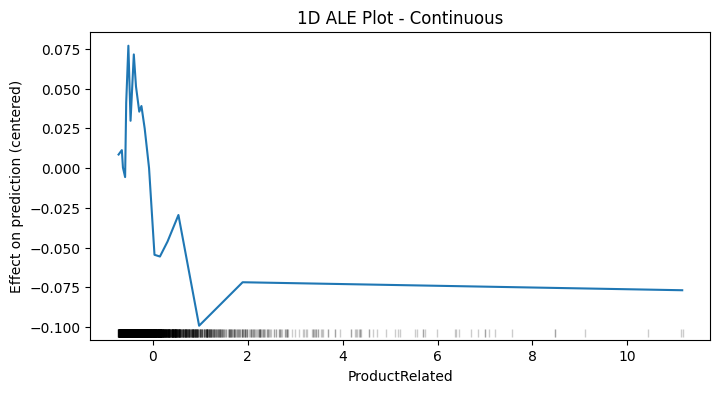

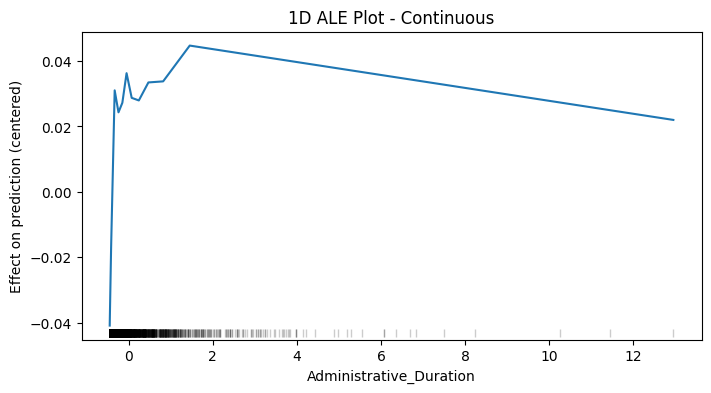

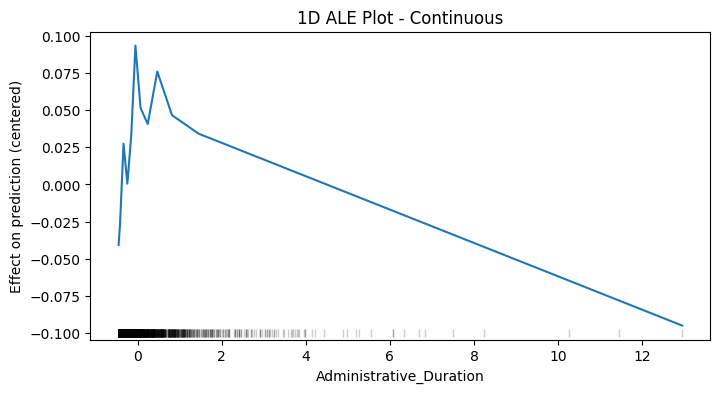

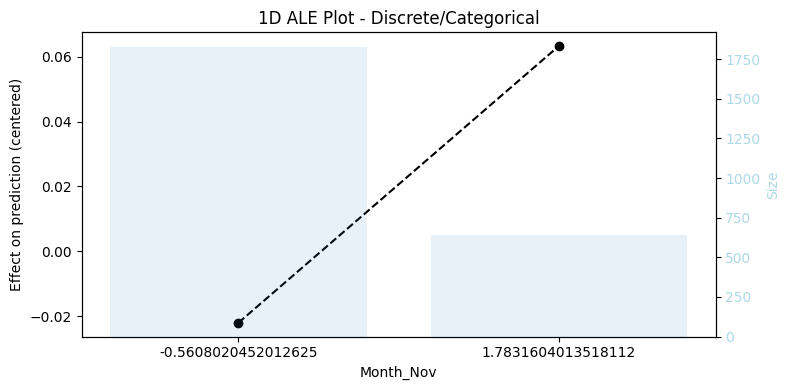

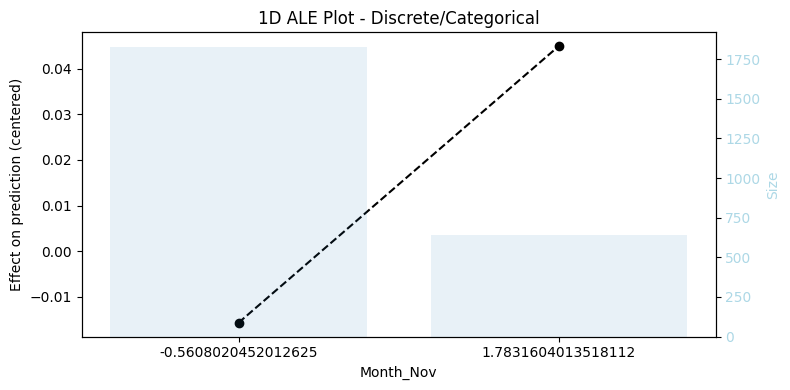

In [19]:
rf_early = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=3, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_early.fit(X_train_s_early, y_train_early)

class ProbaWrapper:
    def __init__(self, fitted_model):
        self.model = fitted_model
    def predict(self, X):
        return self.model.predict_proba(X)[:, 1]

rf_wrapped_pdi  = ProbaWrapper(rf_early)
xgb_wrapped_pdi = ProbaWrapper(xgb_early_model)

# Same feature list already used for your ALE validation, so PDI results are
# directly comparable to the ALE figures already in the manuscript. Extend
# this list to your top-8 SHAP features if you want broader coverage.
pdi_features = [
    ("ProductRelated_Duration", "continuous"),
    ("ProductRelated",          "continuous"),
    ("Administrative_Duration", "continuous"),
    ("Month_Nov",                "discrete"),
]

GRID_SIZE = 20
pdi_rows = []

for feat, ftype in pdi_features:
    ale_rf = ale(X=X_test_s_early_df, model=rf_wrapped_pdi, feature=[feat],
                 feature_type=ftype, grid_size=GRID_SIZE, include_CI=False)
    ale_xgb = ale(X=X_test_s_early_df, model=xgb_wrapped_pdi, feature=[feat],
                  feature_type=ftype, grid_size=GRID_SIZE, include_CI=False)

    if ftype == "continuous":
        # Align on the shared grid (both computed from the same X, so indices
        # should match; reindex defensively in case of minor bin differences)
        common_idx = ale_rf.index.intersection(ale_xgb.index)
        eff_rf  = ale_rf.loc[common_idx, "eff"].values
        eff_xgb = ale_xgb.loc[common_idx, "eff"].values

        # Empirical derivative = first differences between consecutive grid points
        der_rf  = np.diff(eff_rf)
        der_xgb = np.diff(eff_xgb)

        sign_rf  = np.sign(der_rf)
        sign_xgb = np.sign(der_xgb)
        # Treat exact-zero slope as its own sign per Eq. 9; disagreement = signs differ
        disagreement = (sign_rf != sign_xgb)
        pdi_value = disagreement.mean()  # Eq. 9: fraction of m grid points disagreeing

    else:  # discrete/dummy feature — categorical fallback (see note above)
        eff_rf  = ale_rf["eff"].values
        eff_xgb = ale_xgb["eff"].values
        # Direction of effect between the two category levels (e.g. 0 -> 1)
        dir_rf  = np.sign(eff_rf[-1] - eff_rf[0])
        dir_xgb = np.sign(eff_xgb[-1] - eff_xgb[0])
        pdi_value = float(dir_rf != dir_xgb)  # 0 = same direction, 1 = opposite

    pdi_rows.append({
        "feature": feat,
        "feature_type": ftype,
        "PDI_RF_vs_XGBoost": round(float(pdi_value), 4)
    })

pdi_table = pd.DataFrame(pdi_rows)
pdi_table.to_csv("pdi_rf_vs_xgb_early.csv", index=False)

print(pdi_table)
print(f"\nMean PDI across features: {pdi_table['PDI_RF_vs_XGBoost'].mean():.4f}")

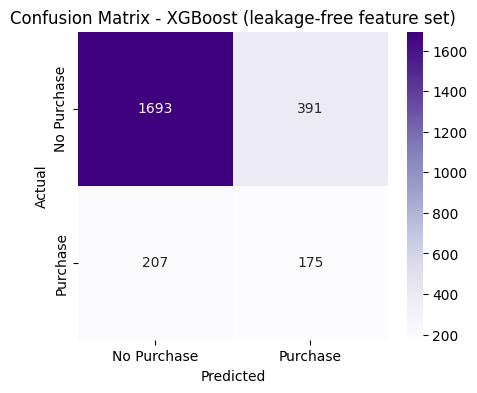

In [20]:
y_pred_xgb_early = xgb_early_model.predict(X_test_s_early)
cm = confusion_matrix(y_test_early, y_pred_xgb_early)

import seaborn as sns
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["No Purchase", "Purchase"],
            yticklabels=["No Purchase", "Purchase"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost (leakage-free feature set)")
plt.savefig("confusion_matrix_xgb_early.png", dpi=200, bbox_inches="tight")
plt.show()


In [21]:
joblib.dump(xgb_early_model, "shopping_model_xgb_early.pkl")
joblib.dump(xgb_full_model, "shopping_model_xgb_full.pkl")

print("Saved:")
print(" - model_comparison_lr_rf_xgb.csv        (Table 1 with XGBoost row)")
print(" - leakage_ablation_results_with_xgb.csv  (Table 3 with XGBoost rows)")
print(" - shap_importance_table_xgb_early.csv    (XGBoost SHAP ranking, leakage-free)")
print(" - shap_comparison_rf_vs_xgb_early.csv    (RF vs XGBoost rank comparison)")
print(" - ale_xgb_ProductRelated_Duration.png, ale_xgb_ProductRelated.png,")
print("   ale_xgb_Administrative_Duration.png, ale_xgb_Month_Nov.png")
print(" - confusion_matrix_xgb_early.png")
print(" - shopping_model_xgb_early.pkl, shopping_model_xgb_full.pkl")
print()
print(f"Spearman rho (RF vs XGBoost leakage-free SHAP ranking): {rho:.3f}")


Saved:
 - model_comparison_lr_rf_xgb.csv        (Table 1 with XGBoost row)
 - leakage_ablation_results_with_xgb.csv  (Table 3 with XGBoost rows)
 - shap_importance_table_xgb_early.csv    (XGBoost SHAP ranking, leakage-free)
 - shap_comparison_rf_vs_xgb_early.csv    (RF vs XGBoost rank comparison)
 - ale_xgb_ProductRelated_Duration.png, ale_xgb_ProductRelated.png,
   ale_xgb_Administrative_Duration.png, ale_xgb_Month_Nov.png
 - confusion_matrix_xgb_early.png
 - shopping_model_xgb_early.pkl, shopping_model_xgb_full.pkl

Spearman rho (RF vs XGBoost leakage-free SHAP ranking): 0.965


In [22]:
from sklearn.metrics import brier_score_loss

def expected_calibration_error(y_true, y_prob, n_bins=10):
    import numpy as np
    y_true = np.asarray(y_true); y_prob = np.asarray(y_prob)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    N = len(y_true)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (y_prob >= lo) & (y_prob <= hi) if i == n_bins - 1 else (y_prob >= lo) & (y_prob < hi)
        n = mask.sum()
        if n == 0:
            continue
        ece += (n / N) * abs(y_true[mask].mean() - y_prob[mask].mean())
    return ece

y_prob_xgb_full = xgb_full_model.predict_proba(X_test_s_full)[:, 1]

brier_xgb = brier_score_loss(y_test_full, y_prob_xgb_full)
ece_xgb = expected_calibration_error(y_test_full, y_prob_xgb_full)

print("XGBoost (full feature set) Brier score:", round(brier_xgb, 4))
print("XGBoost (full feature set) ECE:", round(ece_xgb, 4))

XGBoost (full feature set) Brier score: 0.0858
XGBoost (full feature set) ECE: 0.0547


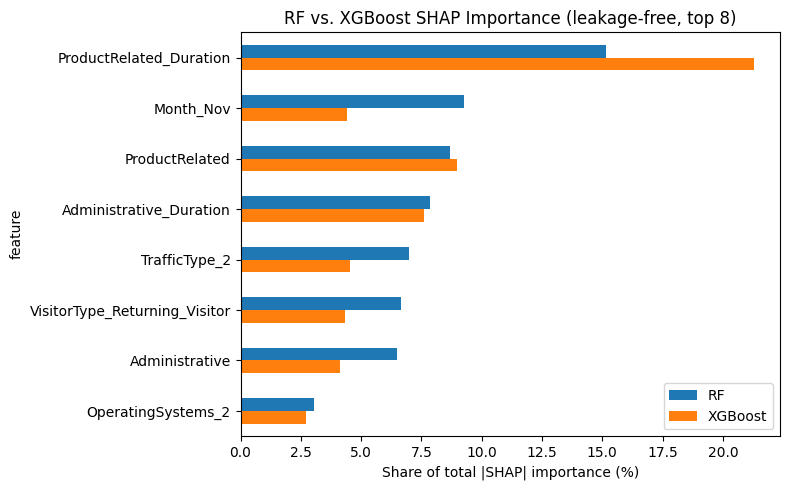

In [23]:
rf = pd.read_csv('shap_importance_table_rf_early.csv')
xgb = pd.read_csv('shap_importance_table_xgb_early.csv')

rf['pct'] = rf['mean_abs_shap'] / rf['mean_abs_shap'].sum() * 100
xgb['pct'] = xgb['mean_abs_shap'] / xgb['mean_abs_shap'].sum() * 100

top8 = rf.sort_values('rank').head(8)['feature']
df = pd.DataFrame({'feature': top8}) \
        .merge(rf[['feature', 'pct']], on='feature').rename(columns={'pct': 'RF'}) \
        .merge(xgb[['feature', 'pct']], on='feature').rename(columns={'pct': 'XGBoost'})

df.plot(x='feature', y=['RF', 'XGBoost'], kind='barh', figsize=(8, 5))
plt.xlabel('Share of total |SHAP| importance (%)')
plt.title('RF vs. XGBoost SHAP Importance (leakage-free, top 8)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('figure_4c_rf_vs_xgb_shap.png', dpi=200)
plt.show()